### Data Normalization: MinMax, Standard and Robust scalers

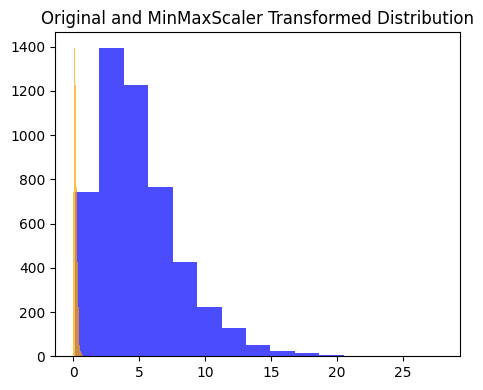

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler,MinMaxScaler,StandardScaler

# Generate random data
np.random.seed(0)
data = np.random.normal(loc=2, scale=3, size=1000)
data = np.random.chisquare(5, size=5000)

# Reshape data for sklearn's RobustScaler
data = data.reshape(-1, 1)

# Apply RobustScaler transformation
scaler = RobustScaler() # StandardScaler, MinMaxScaler, RobustScaler

scaler = MinMaxScaler()
transformed_data = scaler.fit_transform(data)

# Plot histograms
plt.figure(figsize=(9, 4))

# Original and transformed distributions
plt.subplot(1, 2, 1)
plt.hist(data, bins=15, color='blue', alpha=0.7)
plt.hist(transformed_data, bins=15, color='orange', alpha=0.7)
plt.title('Original and MinMaxScaler Transformed Distribution')


plt.tight_layout()
plt.show()

### Effect of outliers

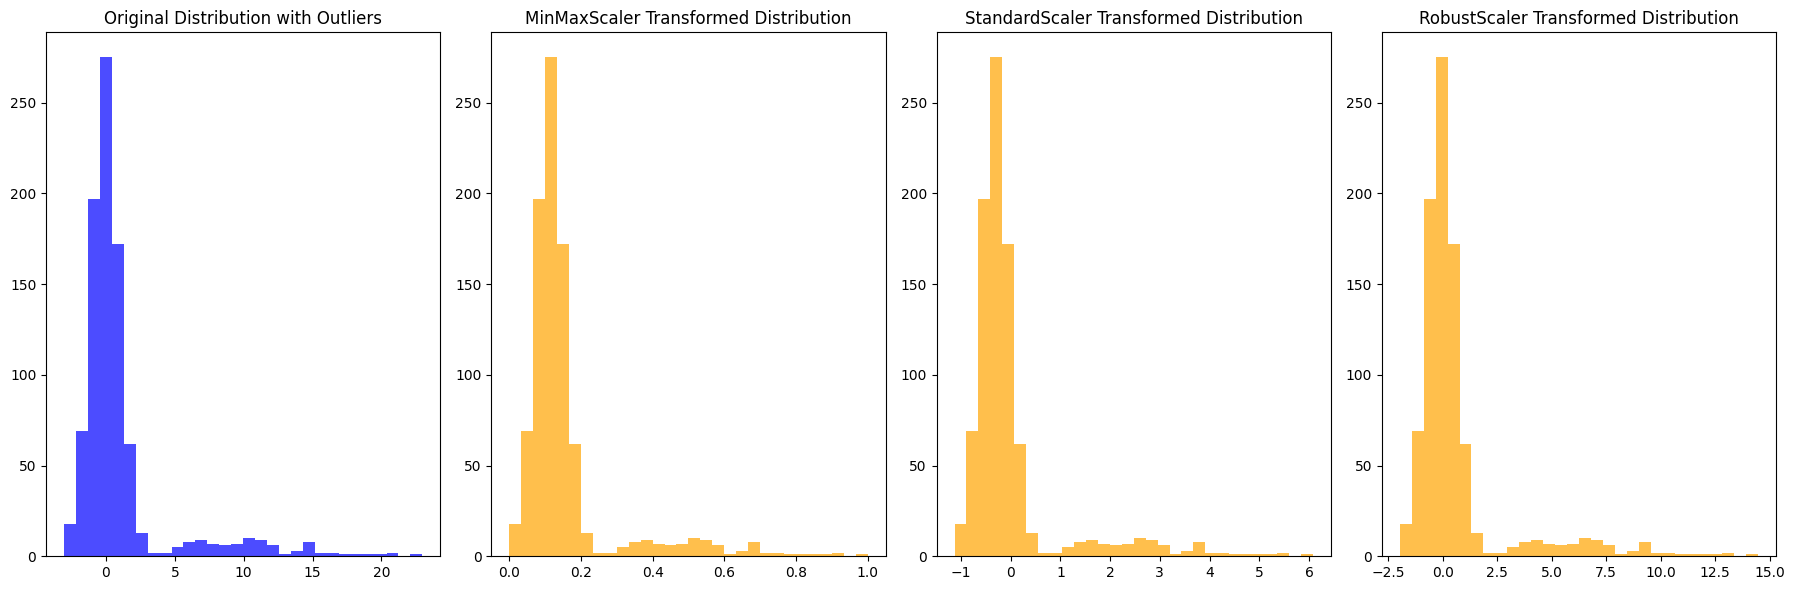

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

# Generate random data with outliers
np.random.seed(0)
data_normal = np.random.normal(loc=0, scale=1, size=800)
data_outliers = np.random.normal(loc=10, scale=5, size=100)
data_with_outliers = np.concatenate((data_normal, data_outliers))

# Reshape data for sklearn scalers
data_with_outliers = data_with_outliers.reshape(-1, 1)

# Apply different rescaling methods
scalers = {
    'MinMaxScaler': MinMaxScaler(),
    'StandardScaler': StandardScaler(),
    'RobustScaler': RobustScaler()
}

transformed_data = {}
for scaler_name, scaler in scalers.items():
    transformed_data[scaler_name] = scaler.fit_transform(data_with_outliers)

# Plot histograms
plt.figure(figsize=(18, 6))

# Original distribution with outliers
plt.subplot(1, 4, 1)
plt.hist(data_with_outliers, bins=30, color='blue', alpha=0.7)
plt.title('Original Distribution with Outliers')

# Plot transformed distributions for each scaler
for i, (scaler_name, data) in enumerate(transformed_data.items(), start=2):
    plt.subplot(1, 4, i)
    plt.hist(data, bins=30, color='orange', alpha=0.7)
    plt.title(f'{scaler_name} Transformed Distribution')

plt.tight_layout()
plt.show()

### Box Cox transformation

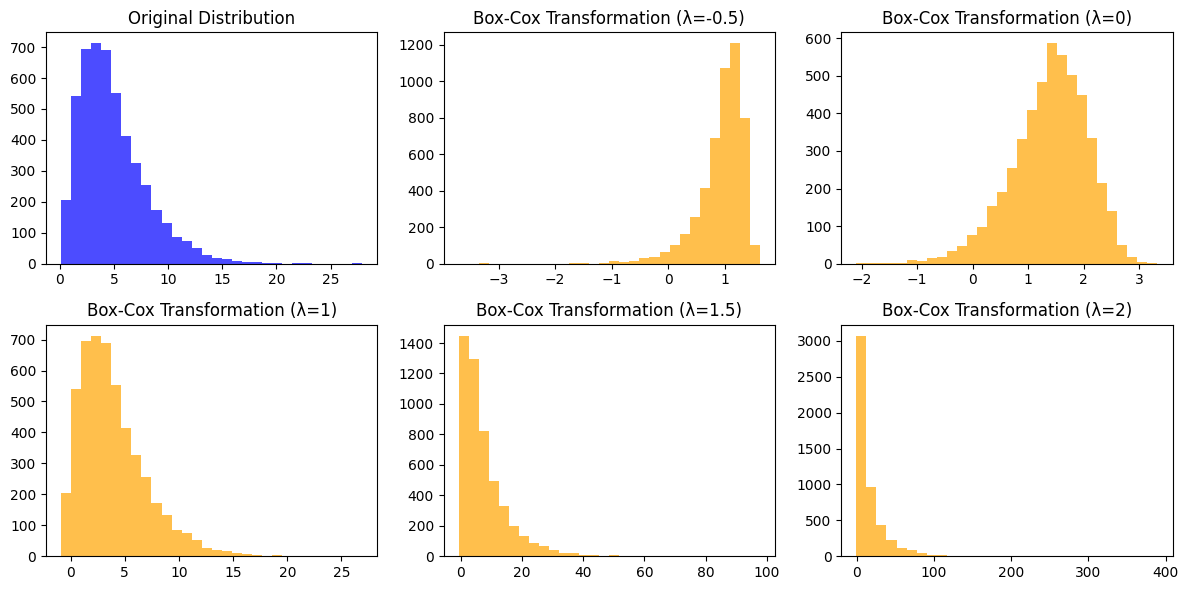

In [3]:
from scipy import stats
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

# Generate random data
np.random.seed(0)
data = np.random.chisquare(5, size=5000)

# Define lambda values for Box-Cox transformation
lambda_values = [-0.5, 0, 1,1.5,2]

# Plot original distribution
plt.figure(figsize=(12, 6))
plt.subplot(2, 3, 1)
plt.hist(data, bins=30, color='blue', alpha=0.7)
plt.title('Original Distribution')

# Apply Box-Cox transformation with different lambda values
for i, lam in enumerate(lambda_values):
    # Perform Box-Cox transformation
    transformed_data = stats.boxcox(data, lmbda=lam)

    # Plot transformed distribution
    plt.subplot(2, 3, i+2)
    plt.hist(transformed_data, bins=30, color='orange', alpha=0.7)
    plt.title(f'Box-Cox Transformation (λ={lam})')

plt.tight_layout()
plt.show()

### Quantile-rank transformation

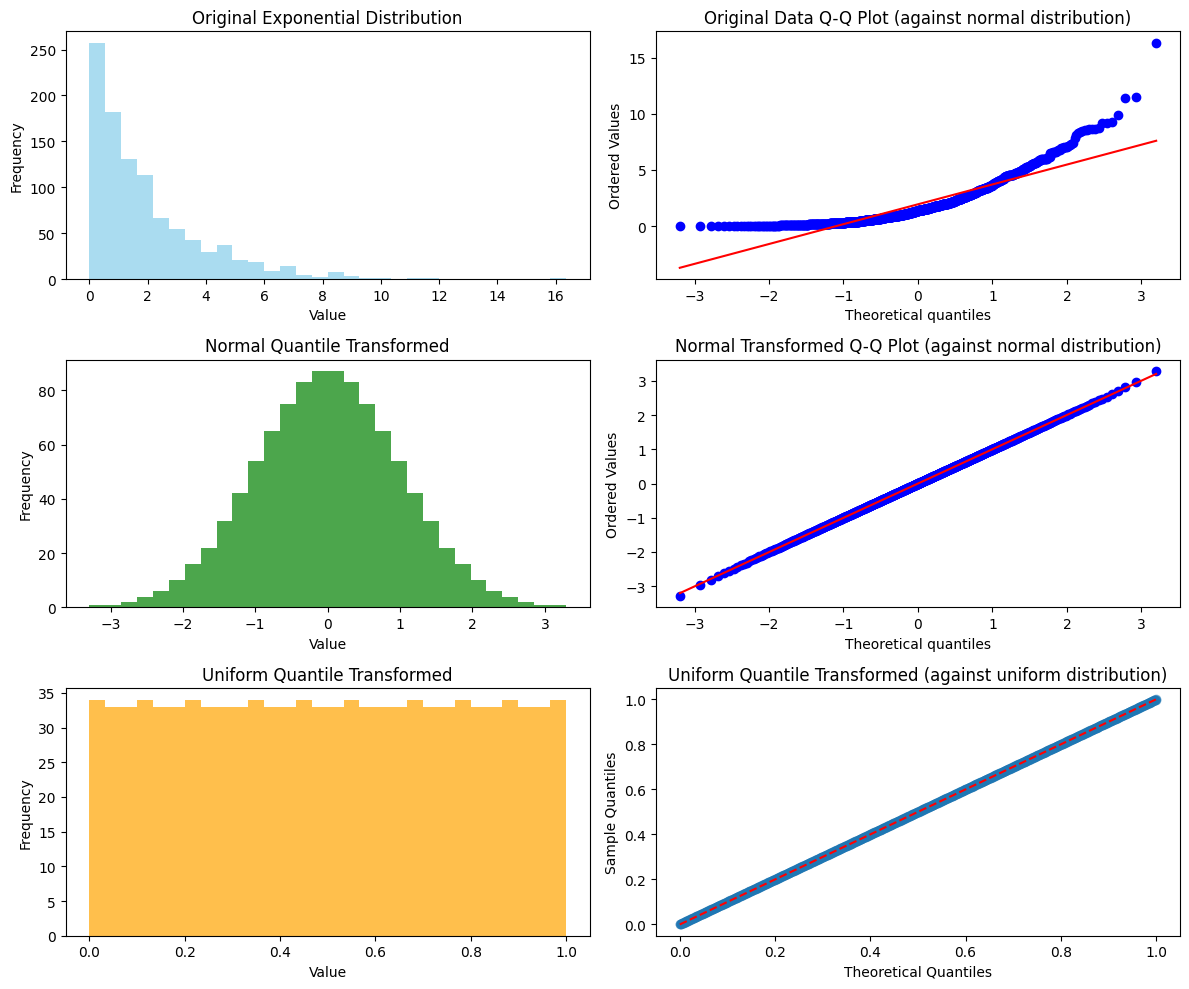

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd


# Create a function for quantile transformation
def quantile_transform(data, output_distribution='normal'):
    """
    Apply a quantile transformation to map data to a specified distribution
    
    Parameters:
    -----------
    data : array-like
        The data to transform
    output_distribution : str, default='normal'
        Target distribution: 'normal' or 'uniform'
        
    Returns:
    --------
    transformed_data : array-like
        The transformed data
    """
    # Calculate the ranks of the observations
    n = len(data)
    ranks = stats.rankdata(data, method='average')
    
    # Convert ranks to quantiles in (0,1)
    # Using (ranks - 0.5)/n formula, which is a common estimator
    quantiles = (ranks - 0.5) / n
    
    if output_distribution == 'normal':
        # Apply inverse CDF of standard normal to get normally distributed data
        transformed_data = stats.norm.ppf(quantiles)
    elif output_distribution == 'uniform':
        # For uniform, the quantiles themselves are already uniformly distributed
        transformed_data = quantiles
    else:
        raise ValueError("Output distribution must be 'normal' or 'uniform'")
        
    return transformed_data




# Generate sample data with a skewed distribution (in this case an exponential distribution)
np.random.seed(42)
original_data = np.random.exponential(scale=2, size=1000)

# Apply transformations
normal_transformed = quantile_transform(original_data, 'normal')
uniform_transformed = quantile_transform(original_data, 'uniform')

# Create plots to visualize the transformations
fig, axs = plt.subplots(3, 2, figsize=(12, 10))

# Original data
axs[0, 0].hist(original_data, bins=30, color='skyblue', alpha=0.7)
axs[0, 0].set_title('Original Exponential Distribution')
axs[0, 0].set_xlabel('Value')
axs[0, 0].set_ylabel('Frequency')

# Original QQ plot
stats.probplot(original_data, dist="norm", plot=axs[0, 1])
axs[0, 1].set_title('Original Data Q-Q Plot (against normal distribution)')

# Normal transformed
axs[1, 0].hist(normal_transformed, bins=30, color='green', alpha=0.7)
axs[1, 0].set_title('Normal Quantile Transformed')
axs[1, 0].set_xlabel('Value')
axs[1, 0].set_ylabel('Frequency')

# Normal QQ plot
stats.probplot(normal_transformed, dist="norm", plot=axs[1, 1])
axs[1, 1].set_title('Normal Transformed Q-Q Plot (against normal distribution)')

# Uniform transformed
axs[2, 0].hist(uniform_transformed, bins=30, color='orange', alpha=0.7)
axs[2, 0].set_title('Uniform Quantile Transformed')
axs[2, 0].set_xlabel('Value')
axs[2, 0].set_ylabel('Frequency')

# Uniform distribution should be a straight line when plotted against uniform quantiles
uniform_theoretical = np.linspace(0, 1, len(uniform_transformed))
uniform_theoretical.sort()
axs[2, 1].scatter(uniform_theoretical, np.sort(uniform_transformed), alpha=0.5)
axs[2, 1].plot([0, 1], [0, 1], 'r--')
axs[2, 1].set_title('Uniform Quantile Transformed (against uniform distribution)')
axs[2, 1].set_xlabel('Theoretical Quantiles')
axs[2, 1].set_ylabel('Sample Quantiles')

plt.tight_layout()
plt.show()


### Variable dummification

In [5]:
import pandas as pd
# creating the dictionary
dictionary = {'OUTLOOK': ['Rainy', 'Rainy',
                          'Overcast', 'Sunny',
                          'Sunny', 'Sunny',
                          'Overcast', 'Rainy',
                          'Rainy', 'Sunny',
                          'Rainy', 'Overcast',
                          'Overcast', 'Sunny'],
              'TEMPERATURE': ['Hot', 'Hot', 'Hot',
                              'Mild', 'Cool',
                              'Cool', 'Cool',
                              'Mild', 'Cool',
                              'Mild', 'Mild',
                              'Mild', 'Hot', 'Mild'],
              'HUMIDITY': ['High', 'High', 'High',
                           'High', 'Normal', 'Normal',
                           'Normal', 'High', 'Normal',
                           'Normal', 'Normal', 'High',
                           'Normal', 'High'],
              'WINDY': ['No', 'Yes', 'No', 'No', 'No',
                        'Yes', 'Yes', 'No', 'No',
                        'No', 'Yes', 'Yes', 'No',
                        'Yes']}

# converting the dictionary to DataFrame
df = pd.DataFrame(dictionary)

# calling the get_dummies method
# the first parameter mentions the
# the name of the data frame to store the
# new data frame in
# the second parameter is the list of
# columns which if not mentioned
# returns the dummies for all
# categorical columns
df2 = pd.get_dummies(df.copy(), columns = ['WINDY', 'OUTLOOK'])
df2

,TEMPERATURE,HUMIDITY,WINDY_No,WINDY_Yes,OUTLOOK_Overcast,OUTLOOK_Rainy,OUTLOOK_Sunny
0,Hot,High,True,False,False,True,False
1,Hot,High,False,True,False,True,False
2,Hot,High,True,False,True,False,False
3,Mild,High,True,False,False,False,True
4,Cool,Normal,True,False,False,False,True
5,Cool,Normal,False,True,False,False,True
6,Cool,Normal,False,True,True,False,False
7,Mild,High,True,False,False,True,False
8,Cool,Normal,True,False,False,True,False
9,Mild,Normal,True,False,False,False,True


## Outlier detection

Multivariate gaussian via chi2 test

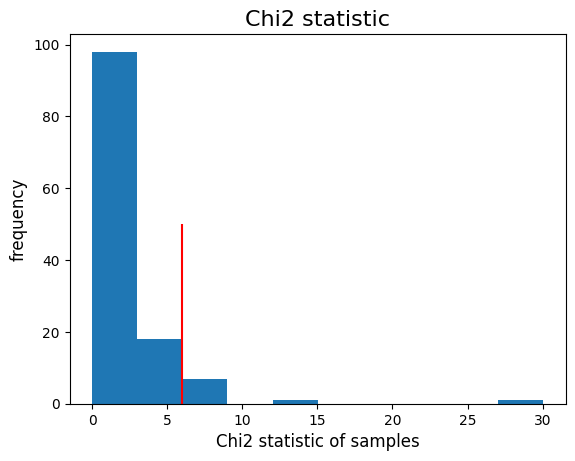

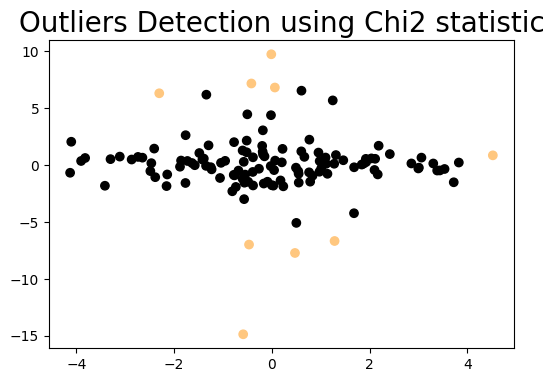

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2
# find which points are outliers based on the chi2 test
# (use the chi2 quantile function, chi2.ppf(quantile, degrees_of_freedom)

# for consistent results
np.random.seed(7)

n_samples = 125
n_outliers = 25
n_features = 2
chi_threshold = 0.99

# generate Gaussian data of shape (125, 2)
gen_cov = np.eye(n_features)
gen_cov[0, 0] = 2.0
X = np.dot(np.random.randn(n_samples, n_features), gen_cov)
# add some outliers
outliers_cov = np.eye(n_features)
outliers_cov[np.arange(1, n_features), np.arange(1, n_features)] = 7.0
X[-n_outliers:] = np.dot(np.random.randn(n_outliers, n_features), outliers_cov)

sample_mu=X.mean(0)
sample_cov_matrix=np.cov(X.T)
Cholesky = np.linalg.cholesky(sample_cov_matrix)
z=np.matmul((X-sample_mu),np.linalg.inv(Cholesky))
chi_threshold=chi2.ppf(0.95, df=n_features)
chi2_sample=np.sum(z**2,1)

outliers=chi2_sample>chi_threshold


plt.hist(chi2_sample)
plt.xlabel('Chi2 statistic of samples',fontsize=12)
plt.ylabel('frequency',fontsize=12)
plt.title('Chi2 statistic',fontsize=16)
plt.vlines(chi_threshold,0,50,color='red')
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(X[:,0], X[:,1], c = outliers, cmap='copper')
plt.title('Outliers Detection using Chi2 statistic',fontsize=20)
plt.show()

### Multivariate gaussian via Mahalanobis distance and chi2

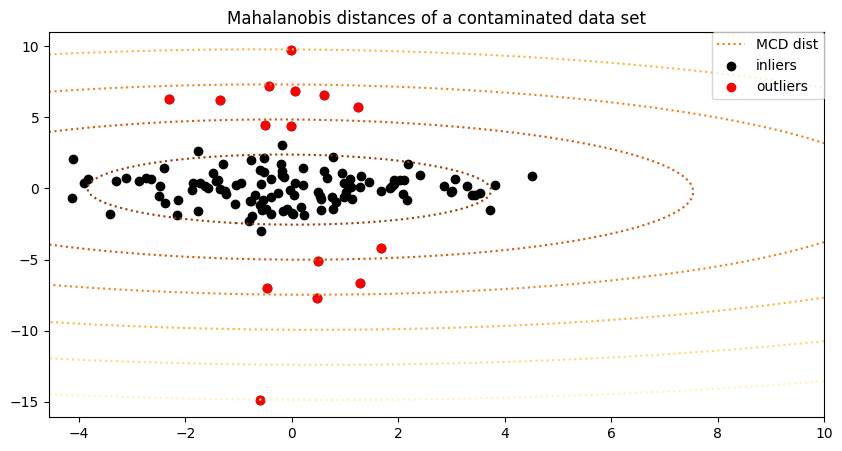

In [7]:
## Example taken from https://scikit-learn.org/stable/auto_examples/covariance/plot_mahalanobis_distances.html

from sklearn.covariance import MinCovDet
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from scipy.stats import chi2


# for consistent results
np.random.seed(7)

n_samples = 125
n_outliers = 25
n_features = 2

# generate Gaussian data of shape (125, 2)
gen_cov = np.eye(n_features)
gen_cov[0, 0] = 2.0
X = np.dot(np.random.randn(n_samples, n_features), gen_cov)
# add some outliers
outliers_cov = np.eye(n_features)
outliers_cov[np.arange(1, n_features), np.arange(1, n_features)] = 7.0
X[-n_outliers:] = np.dot(np.random.randn(n_outliers, n_features), outliers_cov)


# fit a MCD robust estimator to data
robust_cov = MinCovDet().fit(X)
## we can use robust_cov.mahalanobis(X) to compute the square Mahalanobis distance of the list of points in X


fig, ax = plt.subplots(figsize=(10, 5))
# Plot data set
inlier_plot = ax.scatter(X[:, 0], X[:, 1], color="black", label="inliers")
# find outliers based on Chi2 test
bool_outliers = robust_cov.mahalanobis(X)>chi2.ppf(0.99, df=n_features)
#outlier_mixture_plot = ax.scatter(
#    X[:, 0][-n_outliers:], X[:, 1][-n_outliers:], color="blue", label="outliers' source"
#)
outlier_plot = ax.scatter(
    X[:, 0][bool_outliers], X[:, 1][bool_outliers], color="red", label="outliers"
)
ax.set_xlim(ax.get_xlim()[0], 10.0)
ax.set_title("Mahalanobis distances of a contaminated data set")

# Create meshgrid of feature 1 and feature 2 values
xx, yy = np.meshgrid(
    np.linspace(plt.xlim()[0], plt.xlim()[1], 100),
    np.linspace(plt.ylim()[0], plt.ylim()[1], 100),
)
zz = np.c_[xx.ravel(), yy.ravel()]

# Calculate the MCD based Mahalanobis distances
mahal_robust_cov = robust_cov.mahalanobis(zz)
mahal_robust_cov = mahal_robust_cov.reshape(xx.shape)
robust_contour = ax.contour(
    xx, yy, np.sqrt(mahal_robust_cov), cmap=plt.cm.YlOrBr_r, linestyles="dotted"
)

# Add legend
ax.legend(
    [
        mlines.Line2D([], [], color="tab:orange", linestyle="dotted"),
        inlier_plot,
        outlier_plot,
    ],
    [ "MCD dist", "inliers", "outliers"],
    loc="upper right",
    borderaxespad=0,
)

plt.show()

## Kernel density estimation

0.15848931924611134 0.1678756654970775
-5.744431375143988


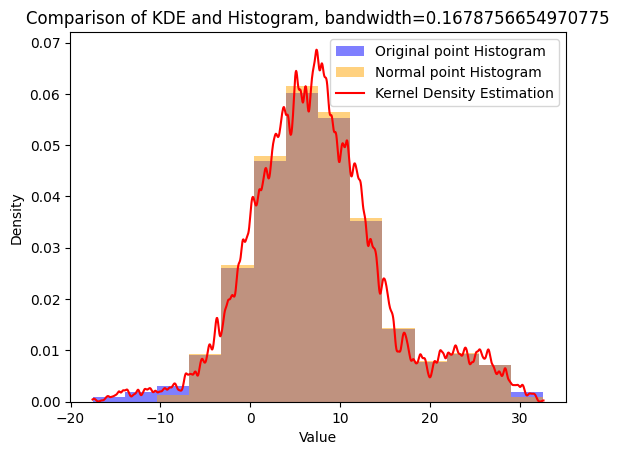

In [8]:
## Taken from: https://machinelearningmastery.com/anomaly-detection-with-isolation-forest-and-kernel-density-estimation/
from sklearn.neighbors import KernelDensity

np.random.seed(135)
def prepData(N):
    X = []
    for i in range(n):
        A = i/1000 + np.random.uniform(-4, 3)
        R = np.random.uniform(-5, 10)
        if(R >= 8.6):
            R = R + 10
        elif(R < (-4.6)):
            R = R +(-9)
        X.append([A + R])
    return np.array(X)

n = 10000
X = prepData(n)


#Scott's Rule: n**(-1. / (d + 4))
n0=len(X)
d=X.shape[1]
scott_bandwidth = n0**(-1/(d+4))
#Silverman's Rule: (n * (d + 2) / 4.)**(-1. / (d + 4)).
silverman_bandwidth = (n0 * (d + 2) / 4.)**(-1. / (d + 4))
print(scott_bandwidth,silverman_bandwidth)

bandwidth=silverman_bandwidth

x_ax = range(n)


kern_dens = KernelDensity(bandwidth=bandwidth)
kern_dens.fit(X)

scores = kern_dens.score_samples(X)
threshold = np.quantile(scores, .02)
print(threshold)

idx = np.where(scores <= threshold)
outliers = X[scores < threshold]
normal = X[scores >= threshold]


# Plot histogram of the original data
plt.hist(X.flatten() , bins=np.linspace(min(X), max(X), 15).flatten(), density=True, alpha=0.5, color='blue', label='Original point Histogram')
# Plot histogram of normal data
plt.hist(normal, bins=np.linspace(min(X), max(X), 15).flatten(), density=True, alpha=0.5, color='orange', label='Normal point Histogram')
# Plot KDE curve
x_plot = np.linspace(min(X), max(X), 1000)
log_likelihood = kern_dens.score_samples(x_plot)
plt.plot(x_plot, np.exp(log_likelihood), color='red', label='Kernel Density Estimation')
plt.xlabel('Value')
plt.ylabel('Density')
plt.title(f'Comparison of KDE and Histogram, bandwidth={bandwidth}')
plt.legend()
plt.show()


### DBSCAN outlier detection

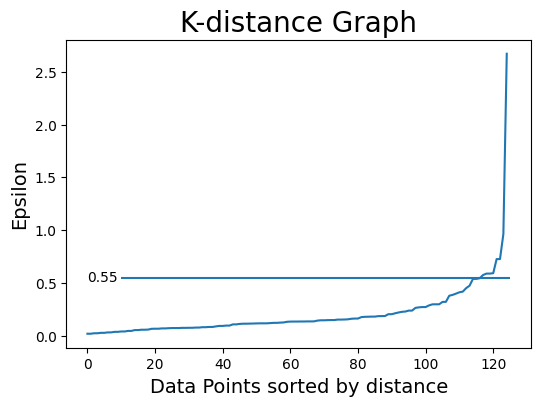

Text(0.5, 1.0, 'Outliers Detection using DBSCAN')

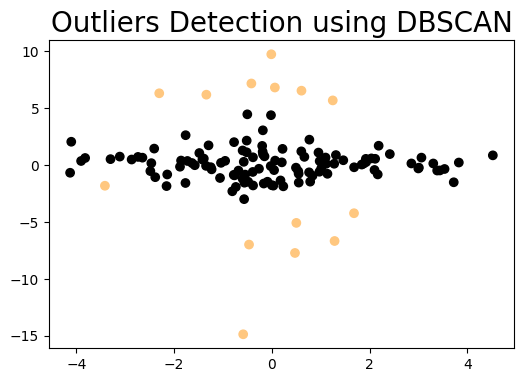

In [9]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

# for consistent results
np.random.seed(7)

n_samples = 125
n_outliers = 25
n_features = 2

#Generate 2D Gaussian data of shape (125, 2)
gen_cov = np.eye(n_features)
gen_cov[0, 0] = 2.0
X = np.dot(np.random.randn(n_samples, n_features), gen_cov)
# add some outliers
outliers_cov = np.eye(n_features)
outliers_cov[np.arange(1, n_features), np.arange(1, n_features)] = 7.0
X[-n_outliers:] = np.dot(np.random.randn(n_outliers, n_features), outliers_cov)


### RESCALE THE DATA
mms = StandardScaler()
Xs = mms.fit_transform(X)

### FIND OPTIMAL KNN DISTANCE
neigh = NearestNeighbors(n_neighbors=2)
nbrs = neigh.fit(Xs)
distances, indices = nbrs.kneighbors(Xs)
# Plotting K-distance Graph
distances = np.sort(distances, axis=0)
distances = distances[:,1]
plt.figure(figsize=(6,4))
plt.plot(distances)
plt.title('K-distance Graph',fontsize=20)
plt.xlabel('Data Points sorted by distance',fontsize=14)
plt.ylabel('Epsilon',fontsize=14,color='k')
plt.hlines(0.55,10,125)
plt.text(0, 0.55, '0.55', ha ='left', va ='center')
plt.show()


### APPLY DBSCAN AND PLOT
model = DBSCAN(eps = 0.55, min_samples = 5).fit(Xs)
labels = model.labels_
plt.figure(figsize=(6,4))
plt.scatter(X[:,0], X[:,1], c = 1-labels, cmap='copper')
plt.title('Outliers Detection using DBSCAN',fontsize=20)

### LOF outlier detection

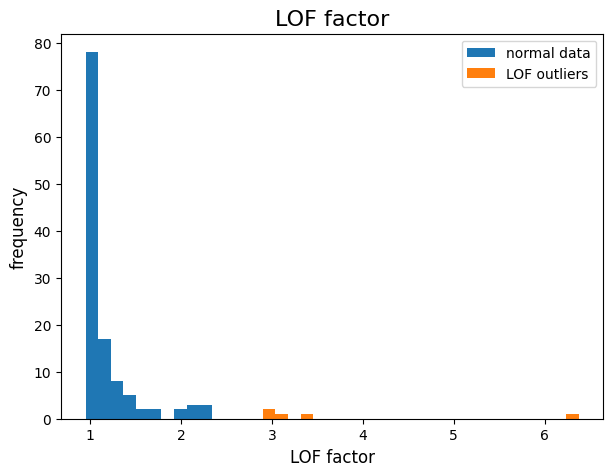

Text(0.5, 1.0, 'Outlier Detection using Local Outlier Factor')

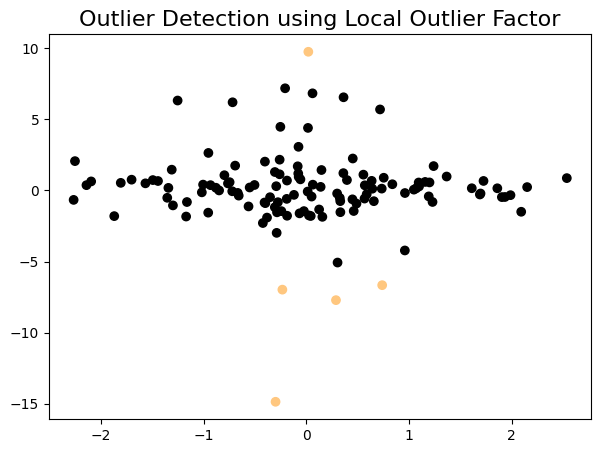

In [10]:

from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

# for consistent results
np.random.seed(7)

n_samples = 125
n_outliers = 25
n_features = 2

# generate Gaussian data of shape (125, 2)
gen_cov = np.eye(n_features)
gen_cov[0, 0] = 2.0
X = np.dot(np.random.randn(n_samples, n_features), gen_cov)
# add some outliers
outliers_cov = np.eye(n_features)
outliers_cov[np.arange(1, n_features), np.arange(1, n_features)] = 7.0
X[-n_outliers:] = np.dot(np.random.randn(n_outliers, n_features), outliers_cov)


### RESCALE THE DATA
mms = StandardScaler()
Xs = mms.fit_transform(X)

# Fit the model for outlier detection (default)
lof = LocalOutlierFactor(novelty=False,contamination=0.04)
labels = lof.fit_predict(Xs)

# plot LOF scores
lof_scores=-lof.negative_outlier_factor_
plt.figure(figsize=(7,5))
plt.hist(lof_scores[labels>-1],bins=np.linspace(min(lof_scores), max(lof_scores), 40),label='normal data')
plt.hist(lof_scores[labels==-1],bins=np.linspace(min(lof_scores), max(lof_scores), 40),label='LOF outliers')
plt.xlabel('LOF factor',fontsize=12)
plt.ylabel('frequency',fontsize=12)
plt.title('LOF factor',fontsize=16)
plt.legend()
plt.show()

# In sklearn, -1 is an outlier.
plt.figure(figsize=(7,5))
plt.scatter(Xs[:,0], X[:,1], c = 1-labels, cmap='copper')
plt.title('Outlier Detection using Local Outlier Factor',fontsize=16)

Interplay between feature transformation and outlier detection

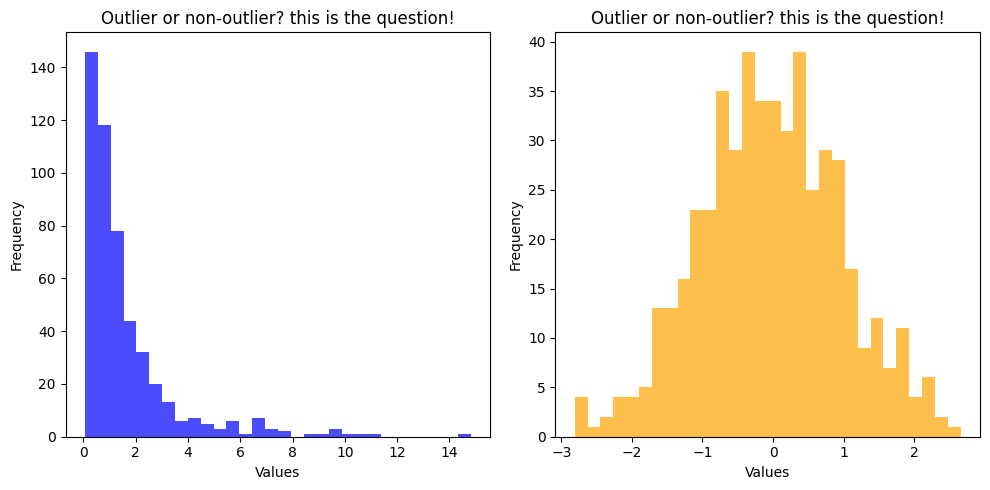

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm
from sklearn.preprocessing import PowerTransformer
from scipy.stats import boxcox

# Generate data from a log-normal distribution
np.random.seed(0)
data_lognormal = lognorm.rvs(s=1, loc=0, scale=1, size=500)

# Plot the histogram of the original data
plt.figure(figsize=(10, 5))
ax1=plt.subplot(1, 2, 1)
ax1.hist(data_lognormal, bins=30, color='blue', alpha=0.7)
ax1.set_title('Outlier or non-outlier? this is the question!')
ax1.set_xlabel('Values')
ax1.set_ylabel('Frequency')

# Apply Box-Cox transformation
data_transformed, _ = boxcox(data_lognormal)

# Plot the histogram of the transformed data
ax2=plt.subplot(1, 2, 2)
ax2.hist(data_transformed, bins=30, color='orange', alpha=0.7)
ax2.set_title('Outlier or non-outlier? this is the question!')
ax2.set_xlabel('Values')
ax2.set_ylabel('Frequency')
plt.tight_layout()

plt.show()